---
#### Practise: Unsupervised Learning: Anomaly detection, Clustering

##### Date: 2026-01-26

Dataset: OnlineRetail 

In [1]:
import pandas as pd

df = pd.read_excel('Online Retail.xlsx') # !! замінити на свій шлях !!

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


---
Task 1. EDA 

In [5]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.tail(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [7]:
df.sample(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
355821,567972,85178,VICTORIAN SEWING KIT,12,2011-09-23 10:14:00,1.25,13949.0,United Kingdom
463722,576070,22243,5 HOOK HANGER RED MAGIC TOADSTOOL,2,2011-11-13 15:58:00,1.65,13451.0,United Kingdom


In [8]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [11]:
df['Country'].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [16]:
df.shape

(541909, 8)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [19]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [15]:
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [23]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2369
REGENCY CAKESTAND 3 TIER               2200
JUMBO BAG RED RETROSPOT                2159
PARTY BUNTING                          1727
LUNCH BAG RED RETROSPOT                1638
                                       ... 
Missing                                   1
historic computer difference?....se       1
DUSTY PINK CHRISTMAS TREE 30CM            1
WRAP BLUE RUSSIAN FOLKART                 1
PINK BERTIE MOBILE PHONE CHARM            1
Name: count, Length: 4223, dtype: int64

In [22]:
df.groupby('Description')['InvoiceNo'].count()

Description
20713                               1
 4 PURPLE FLOCK DINNER CANDLES     41
 50'S CHRISTMAS GIFT BAG LARGE    130
 DOLLY GIRL BEAKER                181
 I LOVE LONDON MINI BACKPACK       88
                                 ... 
wrongly marked carton 22804         1
wrongly marked. 23343 in box        1
wrongly sold (22719) barcode        1
wrongly sold as sets                1
wrongly sold sets                   1
Name: InvoiceNo, Length: 4223, dtype: int64

In [13]:
df[df['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


---
Task 2. Preprocessing (clear data and delete NaN) + create columns TotalPrice + create snapshot_date ( max date )

In [ ]:
# 1. What delete? 
# 2. Delete
# 3. What we delete in step 2?

In [24]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [25]:
df = df.dropna(subset = ['CustomerID'])

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

snapshot_date = df['InvoiceDate'].max()

/var/folders/jg/4z3wkn2j4qg_d9rhsgxmg9340000gn/T/ipykernel_58212/2398751611.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


In [27]:
df.shape

(406829, 9)

In [26]:
snapshot_date

Timestamp('2011-12-09 12:50:00')

---
Task 3. Create RFM

In [30]:
df.groupby("CustomerID")['InvoiceNo'].nunique()

CustomerID
12346.0     2
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     3
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4372, dtype: int64

In [28]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]


In [29]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,0.00
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40
...,...,...,...
18280.0,277,1,180.60
18281.0,180,1,80.82
18282.0,7,3,176.60


---
Task 4. Scalling data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()# створити StandardScaler

rfm_scaled = scaler.fit_transform(rfm) # you code

In [33]:
rfm_scaled

array([[ 2.32202285, -0.32936215, -0.23100099],
       [-0.89373323,  0.20610242,  0.29343167],
       [-0.1691956 , -0.11517632, -0.01231622],
       ...,
       [-0.83418219, -0.22226923, -0.20951263],
       [-0.87388289,  1.16993863,  0.02390005],
       [-0.48680114, -0.22226923, -0.00744423]], shape=(4372, 3))

---
Task 5. Fine-tuning K-Means use Elbow Method & Silhouette Score


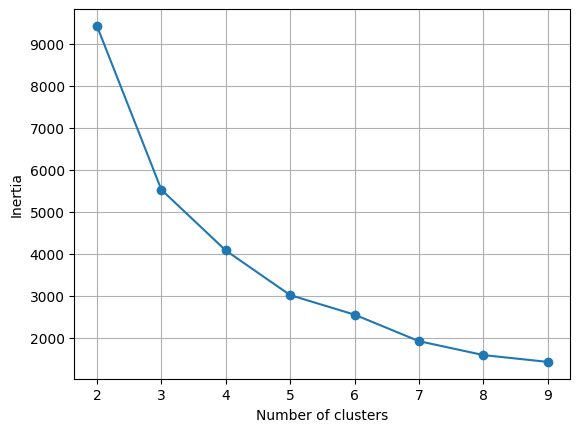

In [39]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# В циклі пройти по кластерах від 2 до 10, та порахувати iteria km.inertia_ (приклад)
inter = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(rfm_scaled)
    inter.append(km.inertia_)
    

plt.plot(K, inter, marker = 'o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid()

2 0.5568161675254506
3 0.5881863741362154
4 0.6142804196098184
5 0.589875763645933
6 0.5152073810193639
7 0.5213735438041367
8 0.493800404777397
9 0.4692562907107869


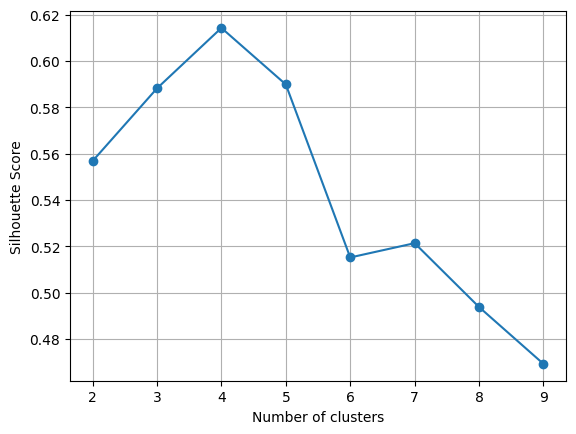

In [41]:
# Silhouette Score
from sklearn.metrics import silhouette_score


sil_score = []
# В циклі пройти по кластерах від 2 до 10, та порахувати silhouette_score 
for k in K:
    km = KMeans(n_clusters = k, random_state = 42)
    labels = km.fit_predict(rfm_scaled)
    print(k, silhouette_score(rfm_scaled, labels))
    sil_score.append(silhouette_score(rfm_scaled, labels))
    

plt.plot(K, sil_score, marker = 'o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid()
    

---
Task 6. Create final model. Add visualization

In [61]:
kmeans = KMeans(n_clusters = 4, random_state = 42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

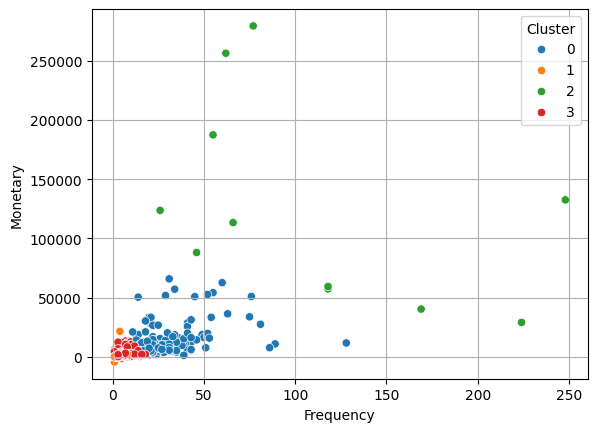

In [62]:
import seaborn as sns

sns.scatterplot(data = rfm, x = 'Frequency', y = 'Monetary', hue = 'Cluster', palette = 'tab10') # tab10
plt.grid()

---
Task 7. Final result and variant of solve

In [58]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,9.752577,28.510309,12168.264691
1,247.927577,1.805942,455.110716
2,4.090909,109.909091,124312.306364
3,41.780906,4.370550,1320.981506


---
Task 8. Anomaly detection. Scalling data 

In [64]:
features = df[["Quantity", "UnitPrice", "TotalPrice"]]

In [65]:
# use StandardScaler
X_scaled = StandardScaler().fit_transform(features)# you code

X_scaled

array([[-0.02437263, -0.01313525, -0.01193162],
       [-0.02437263, -0.00101668, -0.00014466],
       [-0.01633059, -0.01024988,  0.00373756],
       ...,
       [-0.03241467,  0.00994775, -0.00889133],
       [-0.03241467,  0.00994775, -0.00889133],
       [-0.03643569,  0.02148925, -0.01298402]], shape=(406829, 3))

---
Task 9. Isolation Forest. Create model with contamination = 0.01

In [66]:
df.head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.3


In [68]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination = 0.01, random_state = 42)
# you model
iso.fit(X_scaled)
df['IF_score'] = iso.decision_function(X_scaled)
df['IF_anomaly'] = iso.predict(X_scaled)

In [71]:
df['IF_anomaly'].value_counts(normalize = True)

IF_anomaly
 1    0.990094
-1    0.009906
Name: proportion, dtype: float64

---
Task 10. LOF. Create model with n_neighbors = 20 and contamination=0.01

In [72]:
# you code 
from sklearn.neighbors import LocalOutlierFactor 

lof = LocalOutlierFactor(n_neighbors = 20, contamination=0.01)

df['Lof_anomaly'] = lof.fit_predict(X_scaled)

/Users/alksandr/Desktop/kdt_lessons/myenv/lib/python3.10/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [74]:
df['Lof_anomaly'].value_counts()

Lof_anomaly
 1    402761
-1      4068
Name: count, dtype: int64

In [75]:
df[df['Lof_anomaly'] == -1]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IF_score,IF_anomaly,Lof_anomaly
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,0.313218,1,-1
51,536373,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 09:02:00,2.75,17850.0,United Kingdom,22.00,0.313218,1,-1
68,536375,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 09:32:00,2.75,17850.0,United Kingdom,22.00,0.313218,1,-1
82,536376,22114,HOT WATER BOTTLE TEA AND SYMPATHY,48,2010-12-01 09:32:00,3.45,15291.0,United Kingdom,165.60,0.058828,1,-1
102,536378,85071B,RED CHARLIE+LOLA PERSONAL DOORSIGN,96,2010-12-01 09:37:00,0.38,14688.0,United Kingdom,36.48,0.115667,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...
541604,581514,17091J,VANILLA INCENSE IN TIN,66,2011-12-09 11:20:00,0.38,17754.0,United Kingdom,25.08,0.174509,1,-1
541612,581514,21705,BAG 500g SWIRLY MARBLES,84,2011-12-09 11:20:00,0.39,17754.0,United Kingdom,32.76,0.150269,1,-1
541786,581578,22622,BOX OF VINTAGE ALPHABET BLOCKS,6,2011-12-09 12:16:00,11.95,12713.0,Germany,71.70,0.096677,1,-1
541835,581579,23581,JUMBO BAG PAISLEY PARK,40,2011-12-09 12:19:00,1.79,17581.0,United Kingdom,71.60,0.199223,1,-1


In [73]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IF_score,IF_anomaly,Lof_anomaly
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,0.333231,1,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,0.315347,1,1


---
Task 11. Final result

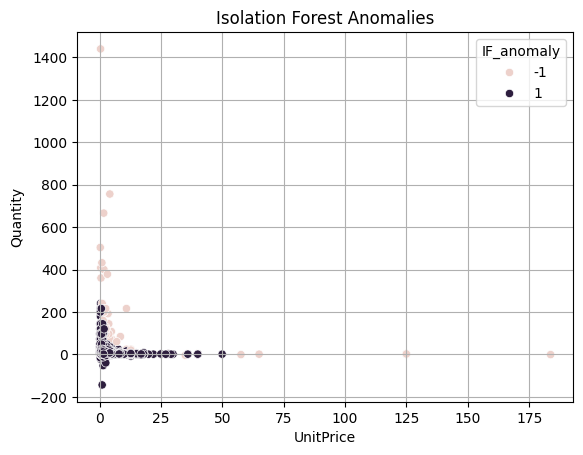

In [78]:
sns.scatterplot(data=df.sample(5000), x="UnitPrice", y="Quantity", hue="IF_anomaly")
plt.title("Isolation Forest Anomalies")

plt.grid()

In [80]:
(df["IF_anomaly"] == -1).mean()

np.float64(0.009905881832416077)

In [84]:
((df["IF_anomaly"] == -1) & (df["Lof_anomaly"] == -1)).sum()

np.int64(429)

In [85]:
for c in [0.005, 0.01, 0.02]:
    iso = IsolationForest(contamination=c, random_state=42)
    preds = iso.fit_predict(X_scaled)
    print(c, (preds == -1).mean())


0.005 0.0049676891273729255
0.01 0.009905881832416077
0.02 0.01995678774128688


In [86]:
for k in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=k, contamination=0.01)
    preds = lof.fit_predict(X_scaled)
    print(k, (preds == -1).mean())


/Users/alksandr/Desktop/kdt_lessons/myenv/lib/python3.10/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


10 0.009986996993822958


/Users/alksandr/Desktop/kdt_lessons/myenv/lib/python3.10/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


20 0.009999287169793697
50 0.009999287169793697


/Users/alksandr/Desktop/kdt_lessons/myenv/lib/python3.10/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [90]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,9.752577,28.510309,12168.264691
1,247.927577,1.805942,455.110716
2,4.090909,109.909091,124312.306364
3,41.780906,4.370550,1320.981506


In [ ]:
# 2 - loyal customer with high ltv(VIP) -> loyal programm 
# 1 - random customer -> low cost 
# 0 - activate customer -> loyal programm
# 3 - passive customer -> discount, re-activate
 

In [91]:
df['IF_anomaly'].value_counts()

IF_anomaly
 1    402799
-1      4030
Name: count, dtype: int64

In [92]:
df[df['IF_anomaly'] == -1].head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IF_score,IF_anomaly,Lof_anomaly
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,15100.0,United Kingdom,350.40,-0.033542,-1,1
178,536387,79321,CHILLI LIGHTS,192,2010-12-01 09:58:00,3.82,16029.0,United Kingdom,733.44,-0.080029,-1,1
179,536387,22780,LIGHT GARLAND BUTTERFILES PINK,192,2010-12-01 09:58:00,3.37,16029.0,United Kingdom,647.04,-0.073768,-1,1
180,536387,22779,WOODEN OWLS LIGHT GARLAND,192,2010-12-01 09:58:00,3.37,16029.0,United Kingdom,647.04,-0.073768,-1,1
181,536387,22466,FAIRY TALE COTTAGE NIGHTLIGHT,432,2010-12-01 09:58:00,1.45,16029.0,United Kingdom,626.40,-0.088730,-1,1


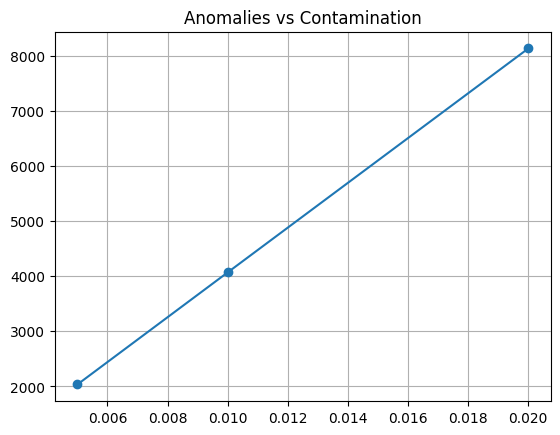

In [89]:
scores = []
conts = [0.005, 0.01, 0.02]

for c in conts:
    iso = IsolationForest(contamination=c)
    preds = iso.fit_predict(X_scaled)
    scores.append((preds == -1).sum())

plt.plot(conts, scores, marker = 'o')
plt.title("Anomalies vs Contamination")
plt.grid()
